# Problem 1:
Simulate  1000 tosses of a biased coin that shows heads (H) with probability 0.7 and tails (T) with probability 0.3.

Plot a histogram of the outcomes.

Compare the observed probabilities with the theoretical probabilities (0.7 and 0.3).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for our simulation
# We represent Heads as 1 and Tails as 0
outcomes = [1, 0]
probabilities = [0.7, 0.3]  # P(Heads) = 0.7, P(Tails) = 0.3
num_tosses = 1000

# Run the simulation
tosses = np.random.choice(outcomes, size=num_tosses, p=probabilities)

# Let's look at the first 20 results
print("First 20 tosses (1=Heads, 0=Tails):")
print(tosses[:20])

First 20 tosses (1=Heads, 0=Tails):
[1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 0 1 1]


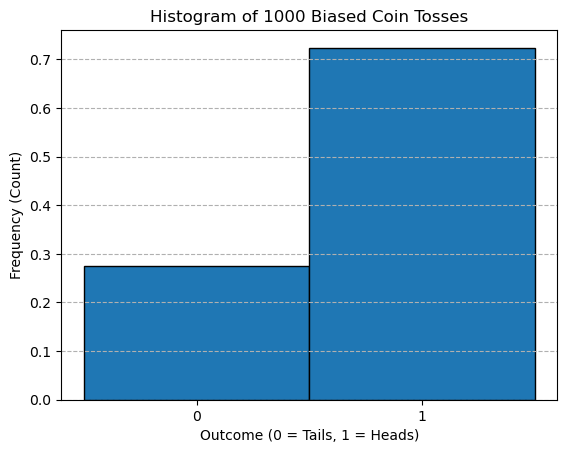

In [3]:
# Plot a histogram of the outcomes
# We can use bins to make the two bars distinct and clear
plt.hist(tosses, bins=[-0.5, 0.5, 1.5], edgecolor='black', density=True)
plt.title("Histogram of 1000 Biased Coin Tosses")
plt.xlabel("Outcome (0 = Tails, 1 = Heads)")
plt.ylabel("Frequency (Count)")
# Set the x-axis ticks to be 0 and 1 for clarity
plt.xticks([0, 1])
plt.grid(True, axis='y', linestyle='--')
plt.show()

In [4]:
# --- Calculate Observed Frequencies ---

# Count the number of heads (outcomes equal to 1)
num_heads = (tosses == 1).sum()

# Count the number of tails (outcomes equal to 0)
num_tails = (tosses == 0).sum()

print(f"Total Tosses: {num_tosses}")
print(f"Number of Heads: {num_heads}")
print(f"Number of Tails: {num_tails}")
print("-" * 30)


# --- Calculate and Compare Probabilities ---

# Observed probability is the count divided by the total number of tosses
prob_heads_observed = num_heads / num_tosses
prob_tails_observed = num_tails / num_tosses

# The theoretical probabilities we defined earlier
prob_heads_theoretical = 0.7
prob_tails_theoretical = 0.3

print("Comparison of Probabilities:")
print(f"Heads (Observed): {prob_heads_observed:.3f}  |  Heads (Theoretical): {prob_heads_theoretical}")
print(f"Tails (Observed): {prob_tails_observed:.3f}  |  Tails (Theoretical): {prob_tails_theoretical}")

Total Tosses: 1000
Number of Heads: 724
Number of Tails: 276
------------------------------
Comparison of Probabilities:
Heads (Observed): 0.724  |  Heads (Theoretical): 0.7
Tails (Observed): 0.276  |  Tails (Theoretical): 0.3



# Problem 2: 
Simulate rolling a fair die 6000 times.

Plot the histogram of outcomes.

Compute observed probabilities of each face (1–6).

Compare with the theoretical probability (1/6 ≈ 0.1667).

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for our simulation
num_rolls = 6000
# A standard die has faces 1, 2, 3, 4, 5, 6.
# So we generate random integers from 1 up to (but not including) 7.
rolls = np.random.randint(low=1, high=7, size=num_rolls)

# Let's look at the first 20 results to see what they look like
print("First 20 die rolls:")
print(rolls[:20])

First 20 die rolls:
[2 3 1 2 1 1 2 1 6 6 5 1 5 4 5 2 1 6 3 2]


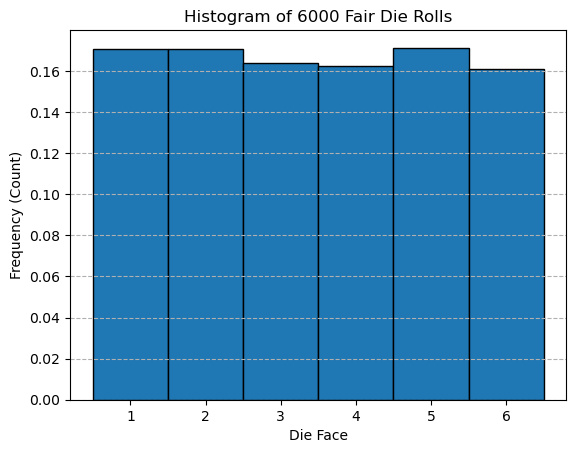

In [7]:
# Define bins to separate each die face clearly in the histogram
# Bins are [0.5, 1.5], [1.5, 2.5], ..., [5.5, 6.5]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]

# Plot a histogram of the outcomes
plt.hist(rolls, bins=bins, edgecolor='black', density=True)
plt.title("Histogram of 6000 Fair Die Rolls")
plt.xlabel("Die Face")
plt.ylabel("Frequency (Count)")
# Set the x-axis ticks to be the die faces for clarity
plt.xticks([1, 2, 3, 4, 5, 6])
plt.grid(True, axis='y', linestyle='--')
plt.show()

In [9]:
# The theoretical probability for a fair die
prob_theoretical = 1 / 6

print(f"Theoretical Probability for each face: {prob_theoretical:.4f}\n")
print("-" * 50)
print("Comparison of Observed vs. Theoretical Probabilities:")
print("-" * 50)

# Loop through each possible outcome (1 to 6)
for face in range(1, 7):
    # Count how many times this face appeared in our 'rolls' array
    count = (rolls == face).sum()

    # Calculate the observed probability
    prob_observed = count / num_rolls

    # Print the comparison
    print(f"Face {face}: Observed = {prob_observed:.4f} | Count = {count}")

Theoretical Probability for each face: 0.1667

--------------------------------------------------
Comparison of Observed vs. Theoretical Probabilities:
--------------------------------------------------
Face 1: Observed = 0.1592 | Count = 955
Face 2: Observed = 0.1652 | Count = 991
Face 3: Observed = 0.1668 | Count = 1001
Face 4: Observed = 0.1713 | Count = 1028
Face 5: Observed = 0.1605 | Count = 963
Face 6: Observed = 0.1770 | Count = 1062


# Problem 3:
For n=50 trials with success probability p=0.5:

Plot the binomial probability mass function (pmf).

Compare it with the corresponding normal distribution approximation.

Normal Approximation Parameters:
Mean (μ) = 25.0
Standard Deviation (σ) = 3.5355


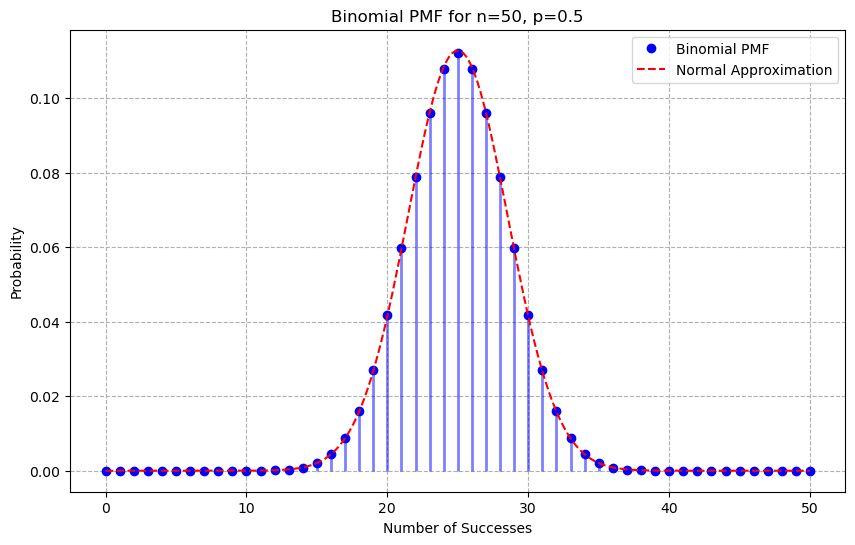

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# Define the parameters for the binomial distribution
n = 50
p = 0.5

# Create a binomial distribution object
binomial_dist = binom(n, p)

# The possible number of successes (x-axis) are integers from 0 to n
x_values = np.arange(0, n + 1)

# Calculate the probability for each possible number of successes
pmf_values = binomial_dist.pmf(x_values)

# Create the plot
plt.figure(figsize=(10, 6))
# We use 'bo' to plot dots for each discrete probability
plt.plot(x_values, pmf_values, 'bo', label='Binomial PMF')
# We use vlines to draw vertical lines from the x-axis to the dots
plt.vlines(x_values, 0, pmf_values, colors='b', alpha=0.5, lw=2)

plt.title(f"Binomial PMF for n={n}, p={p}")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")

# --- Calculate Mean and Standard Deviation for the Normal Approximation ---
mean_mu = n * p
std_dev_sigma = np.sqrt(n * p * (1 - p))

print("Normal Approximation Parameters:")
print(f"Mean (μ) = {mean_mu}")
print(f"Standard Deviation (σ) = {std_dev_sigma:.4f}")


# --- Plot the Normal Distribution PDF on the same graph ---

# For a smooth curve, we use linspace to get many points between 0 and n
x_continuous = np.linspace(0, n, 200)

# Calculate the PDF for the normal distribution
normal_pdf_values = norm.pdf(x_continuous, loc=mean_mu, scale=std_dev_sigma)

# Add the normal curve to our existing plot
plt.plot(x_continuous, normal_pdf_values, 'r--', label='Normal Approximation')

# Add a legend to identify the plots
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Problem 4:
A population of people has weights that are normally distributed with mean 70 kg and standard deviation 10 kg.

# Tasks:

Randomly select 10 values from this population and compute the sample mean.

Repeat this sampling 10,000 times and plot the distribution (histogram) of the sample means.

Repeat the above steps for sample sizes: 5, 10, 20, 40, 80, 100.

For each sample size, overlay a normal distribution with:

Mean = 70

Standard deviation = 10 / √(sample size)

Compare how the distribution of sample means changes with sample size and how it approaches a normal distribution.

(10000, 5)


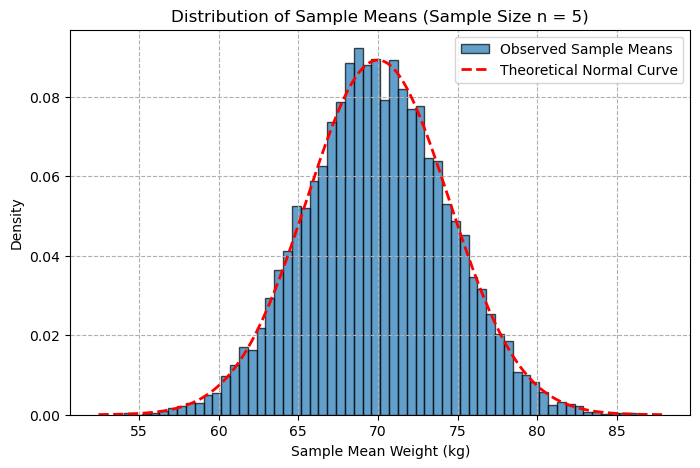

(10000, 10)


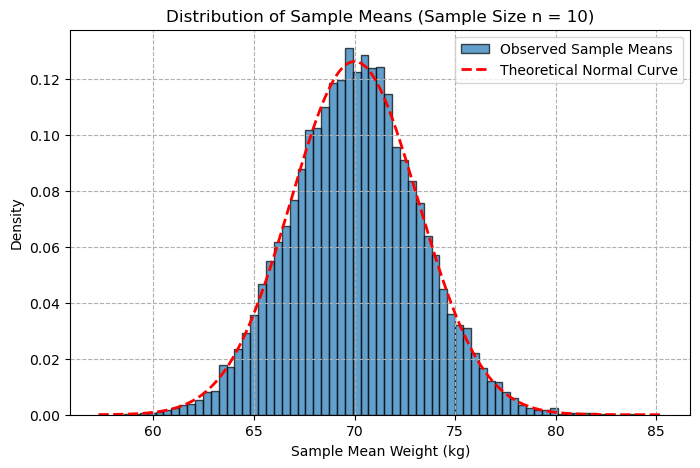

(10000, 20)


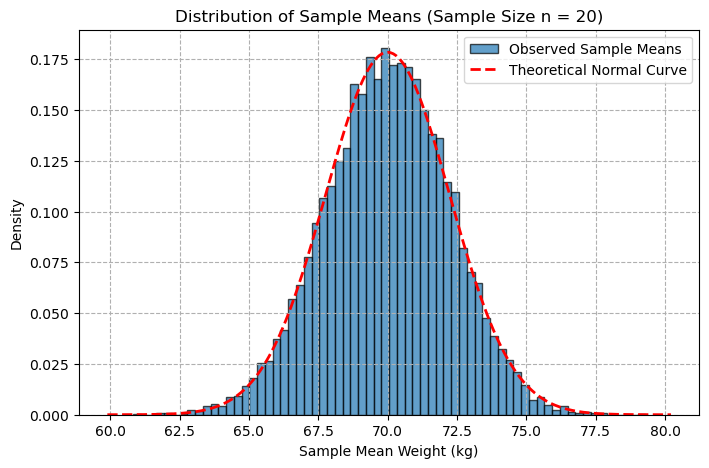

(10000, 40)


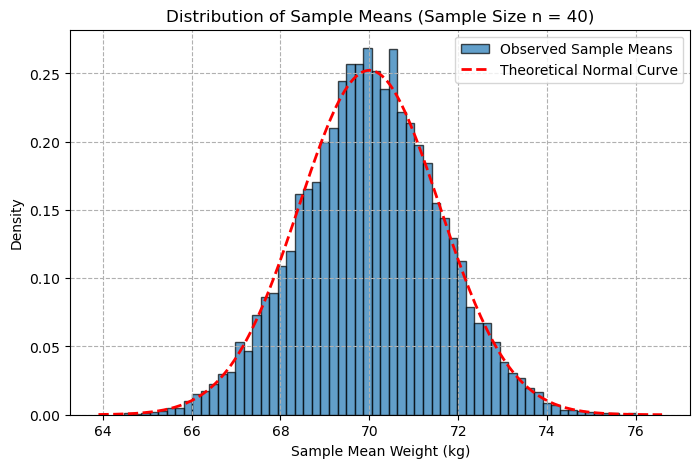

(10000, 80)


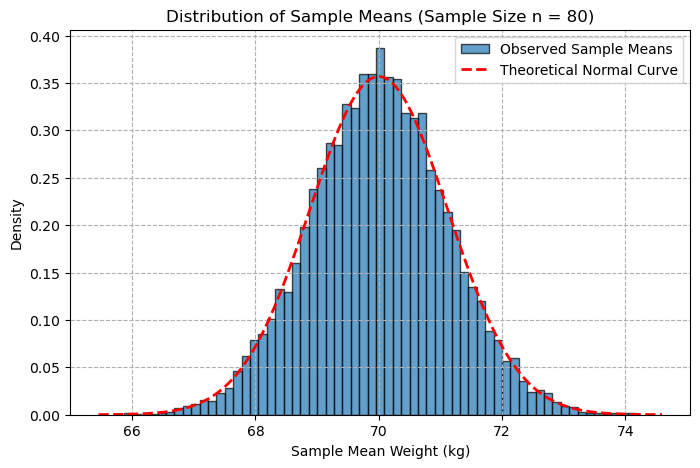

(10000, 100)


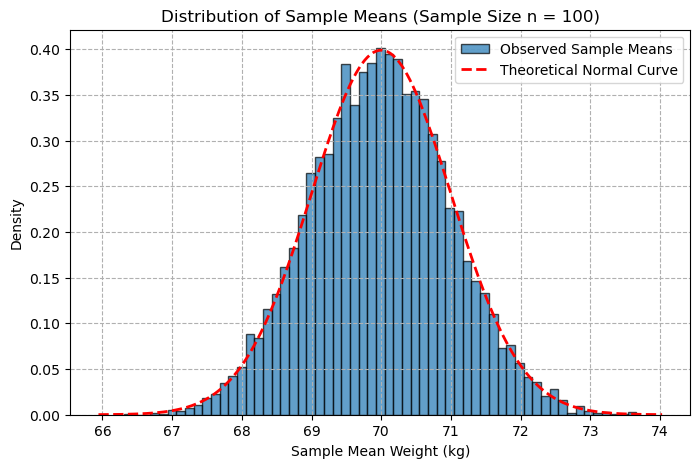

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters of the population distribution
pop_mean = 70.0
pop_std = 10.0

# How many times we repeat the sampling experiment
num_simulations = 10000

# The different sample sizes we will test
sample_sizes = [5, 10, 20, 40, 80, 100]

# Loop through each sample size to perform the experiment
for n in sample_sizes:
    # --- 1. & 2. Simulate Sampling and Compute Means ---
    # Generate all samples at once: 10000 rows, n columns
    all_samples = np.random.normal(loc=pop_mean, scale=pop_std, size=(num_simulations, n))
    print(all_samples.shape)
    # Calculate the mean of each row (each sample)
    sample_means = np.mean(all_samples, axis=1)
    
    # --- 3. Plot the Histogram ---
    plt.figure(figsize=(8, 5))
    plt.hist(sample_means, bins='auto', density=True, edgecolor='black', alpha=0.7, label='Observed Sample Means')
    
    # --- 4. Overlay the Theoretical Normal Distribution ---
    # Mean of the sample means distribution is the same as the population mean
    theoretical_mean = pop_mean
    # Standard deviation of the sample means distribution (Standard Error)
    theoretical_std = pop_std / np.sqrt(n)
    
    # Generate x-values for the theoretical curve
    x_min, x_max = plt.xlim()
    x_values = np.linspace(x_min, x_max, 200)
    
    # Calculate the PDF for the theoretical normal curve
    pdf_values = norm.pdf(x_values, loc=theoretical_mean, scale=theoretical_std)
    
    # Plot the theoretical curve
    plt.plot(x_values, pdf_values, 'r--', lw=2, label='Theoretical Normal Curve')

    # --- Add labels and title for clarity ---
    plt.title(f'Distribution of Sample Means (Sample Size n = {n})')
    plt.xlabel('Sample Mean Weight (kg)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()

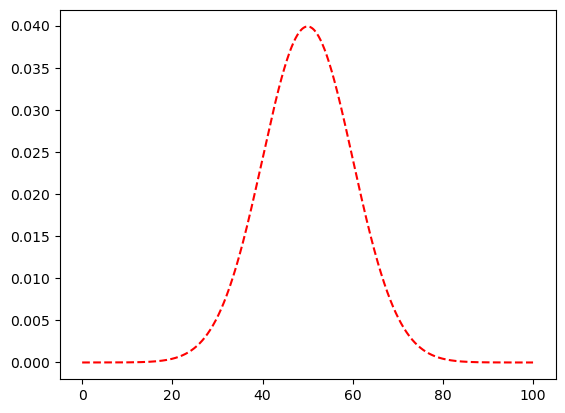

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mean = 50
std = 10

xvalues = np.linspace(0,100,1000)
pdf = norm.pdf(xvalues, loc=mean, scale=std)

plt.plot(xvalues,pdf,'r--')

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm,probplot,expon

## Problem 1

Consider the last problem in problems5.ipynb shared earlier. Repeat the analysis with an exponential distribution. These illustrate the Central Limit Theorem that the sample mean goes towards a normal distribution.

The life of a battery has an exponential distribution with the single parameter $\lambda=1$ , i.e. `np.random.exponential(scale=1)`

Randomly select 10 values from this population and compute the sample mean.

Repeat this sampling 10,000 times and plot the distribution (histogram) of the sample means.

Repeat the above steps for sample sizes: 5, 10, 20, 40, 80, 100.

For each sample size, overlay a normal distribution with:

Mean = 1

Standard deviation = 1 / √(sample size)
